# Model 2: Dropout Prediction - Logistic Regression Baseline

## Overview
This notebook trains a Logistic Regression baseline to predict HIV care gap dropout using cleaned DHS data.

**Target Variable:** `dropout` (1 = HIV+ and no test in 12 months, 0 = retained in care)

**Class Distribution:** 0.08% dropout (26 positive cases out of 32,156)

**Features:** 19 features including demographics, HIV testing history, and encoded education/wealth

In [5]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)
    
import constants as c

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

print("Setup complete")
print(f"Data path: {c.DHS_CLEAN}")
print(f"Features: {len(c.MODEL2_FEATURES)}")
print(f"Target: {c.MODEL2_TARGET}")

Setup complete
Data path: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/individual_features_clean.csv
Features: 18
Target: dropout


## Load Cleaned DHS Data

The cleaned dataset from Task 03 is loaded. It contains 32,156 records with 0% missing values and all categorical variables properly decoded.

In [6]:
# Cell 2: Load Cleaned Data
df = pd.read_csv(c.DHS_CLEAN)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df[c.MODEL2_TARGET].value_counts())
print(f"\nDropout rate: {df[c.MODEL2_TARGET].mean():.4%}")

Dataset: 32,156 rows, 24 columns

Target distribution:
dropout
0    32130
1       26
Name: count, dtype: int64

Dropout rate: 0.0809%


## Feature and Target Preparation

We extract the features defined in `constants.MODEL2_FEATURES` and the target variable `dropout`. Any missing features are reported for transparency.

In [7]:
# Cell 3: Prepare Features and Target
available_features = [col for col in c.MODEL2_FEATURES if col in df.columns]
missing_features = [col for col in c.MODEL2_FEATURES if col not in df.columns]

if missing_features:
    print(f"Warning: {len(missing_features)} features not found:")
    print(missing_features)

X = df[available_features].copy()
y = df[c.MODEL2_TARGET].copy()

print(f"Features shape: {X.shape}")
print(f"Features used: {available_features[:5]}...")

Features shape: (32156, 18)
Features used: ['county', 'age_group', 'marital_status', 'distance_to_facility', 'ever_tested_hiv']...


## Data Type Inspection

We inspect the data types of our features. Only object-type columns (strings) need encoding - numeric and boolean columns are ready for modeling.

In [8]:
# Cell 4: Check Data Types
print("Feature data types:")
print(X.dtypes.value_counts())

print("\nObject columns (need encoding):")
object_cols = X.select_dtypes(include=["object"]).columns.tolist()
if object_cols:
    for col in object_cols:
        print(f"  {col}: {X[col].unique()[:3]}")
else:
    print("  No object columns found - all features are numeric")

Feature data types:
bool       9
object     5
float64    3
int64      1
Name: count, dtype: int64

Object columns (need encoding):
  age_group: ['30-34' '35-39' '25-29']
  marital_status: ['Married' 'Divorced' 'Living together']
  distance_to_facility: [nan '5-10 km' '1-2 km']
  worked_last_12months: ['No' 'Yes' 'Currently working']
  currently_in_union: ['Currently in union' 'Formerly in union' 'Not in union']


## Label Encoding for Categorical Features

We apply label encoding to convert string categories to numeric values. Only object-type columns are encoded - numeric and boolean columns remain unchanged.

**Columns encoded:**
- county, age_group, marital_status, distance_to_facility
- worked_last_12months, currently_in_union

**Note:** Education and wealth are already one-hot encoded (boolean) from Task 03, so they don't need encoding.

In [9]:
# Cell 5: Encode Categorical Columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  Encoded {col}")

print(f"\nAll features now numeric: {X.dtypes.value_counts()}")

Encoding 5 categorical columns: ['age_group', 'marital_status', 'distance_to_facility', 'worked_last_12months', 'currently_in_union']
  Encoded age_group
  Encoded marital_status
  Encoded distance_to_facility
  Encoded worked_last_12months
  Encoded currently_in_union

All features now numeric: bool       9
int64      6
float64    3
Name: count, dtype: int64


## Train/Test Split

We split the data 80/20 with stratification to preserve the class distribution. The split uses:
- `test_size=0.2` (20% for testing)
- `random_state=42` (reproducibility)
- `stratify=y` (maintains dropout rate in both sets)

In [10]:
# Cell 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=c.TEST_SIZE, random_state=c.RANDOM_STATE, stratify=y
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.1%})")
print(f"Train dropout rate: {y_train.mean():.4%}")
print(f"Test dropout rate: {y_test.mean():.4%}")

Training: 25,724 samples (80.0%)
Test: 6,432 samples (20.0%)
Train dropout rate: 0.0816%
Test dropout rate: 0.0777%


## Model Training: Logistic Regression

We train a Logistic Regression model as our baseline with the following hyperparameters:
- `max_iter=1000`: Ensures convergence
- `class_weight='balanced'`: Automatically handles class imbalance
- `solver='lbfgs'`: Efficient optimizer for small datasets
- `random_state=42`: Reproducibility

In [11]:
# Cell 7: Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000, random_state=c.RANDOM_STATE, class_weight="balanced", solver="lbfgs"
)

lr_model.fit(X_train, y_train)
print(f"Training complete ({lr_model.n_iter_[0]} iterations)")

Training complete (362 iterations)


## Generate Predictions

We generate both:
- **Class predictions** (`y_pred`): Binary 0/1 for confusion matrix
- **Probability scores** (`y_pred_proba`): For ROC-AUC calculation

In [12]:
# Cell 8: Make Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Predicted positives: {(y_pred == 1).sum()}")
print(f"Actual positives: {y_test.sum()}")

Predicted positives: 1568
Actual positives: 5


## Performance Metrics

We calculate four key metrics:
| Metric | Description | Target |
|--------|-------------|--------|
| AUC-ROC | Discriminative ability | > 0.70 |
| Recall | % of actual dropouts caught | > 0.60 |
| Precision | % of predicted dropouts correct | > 0.50 |
| F1 Score | Harmonic mean of precision & recall | > 0.55 |

In [13]:
# Cell 9: Calculate Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"AUC-ROC: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
AUC-ROC: 0.7248
Recall: 0.4000
Precision: 0.0013
F1 Score: 0.0025


## Confusion Matrix Analysis

The confusion matrix shows the breakdown of predictions:
- **True Negatives**: Correctly predicted retained
- **False Positives**: Incorrectly predicted dropout (Type I error)
- **False Negatives**: Missed dropouts (Type II error) - Most critical
- **True Positives**: Correctly predicted dropouts

In [14]:
# Cell 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"                 Predicted Retained  Predicted Dropout")
print(f"Actual Retained      {tn:>6,}            {fp:>6,}")
print(f"Actual Dropout       {fn:>6,}            {tp:>6,}")
print("-" * 50)
print(f"True Negatives: {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives: {tp:,}")
print("-" * 50)
print(f"False Positive Rate: {fp/(fp+tn):.4%}")
print(f"False Negative Rate: {fn/(fn+tp):.4%}")

Confusion Matrix:
                 Predicted Retained  Predicted Dropout
Actual Retained       4,861             1,566
Actual Dropout            3                 2
--------------------------------------------------
True Negatives: 4,861
False Positives: 1,566
False Negatives: 3
True Positives: 2
--------------------------------------------------
False Positive Rate: 24.3660%
False Negative Rate: 60.0000%


## Confusion Matrix Visualization

Heatmap provides an intuitive visual representation of classification performance.

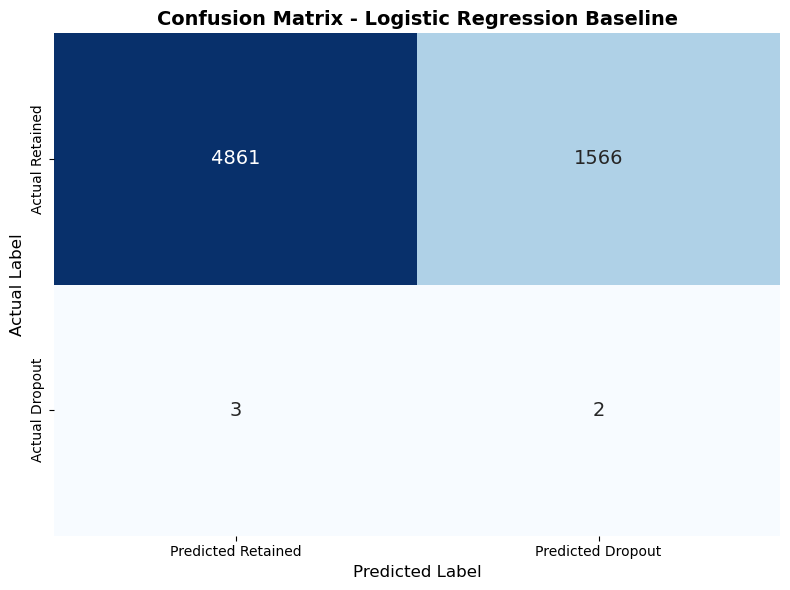

✓ Saved: figures/confusion_matrix_logreg.png


In [15]:
# Cell 11: Confusion Matrix Heatmap
os.makedirs("../figures", exist_ok=True)

cm_df = pd.DataFrame(
    cm,
    columns=["Predicted Retained", "Predicted Dropout"],
    index=["Actual Retained", "Actual Dropout"],
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 14}
)
plt.title(
    "Confusion Matrix - Logistic Regression Baseline", fontweight="bold", fontsize=14
)
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: figures/confusion_matrix_logreg.png")

## ROC Curve Analysis

The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate. The diagonal line (AUC=0.50) represents random guessing.

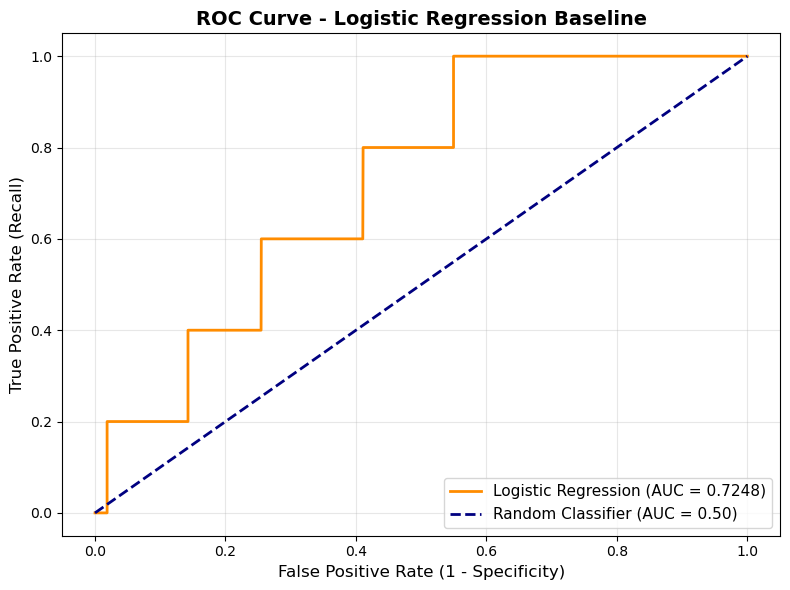

✓ Saved: figures/roc_curve_logreg.png


In [16]:
# Cell 12: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Logistic Regression (AUC = {auc_score:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--",
    label="Random Classifier (AUC = 0.50)",
)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve - Logistic Regression Baseline", fontweight="bold", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/roc_curve_logreg.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: figures/roc_curve_logreg.png")

## Detailed Classification Report

Per-class metrics provide insight into model performance on the minority class (dropout).

In [17]:
# Cell 13: Classification Report
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Retained", "Dropout"]))

Classification Report:
              precision    recall  f1-score   support

    Retained       1.00      0.76      0.86      6427
     Dropout       0.00      0.40      0.00         5

    accuracy                           0.76      6432
   macro avg       0.50      0.58      0.43      6432
weighted avg       1.00      0.76      0.86      6432



## Persist Baseline Results

Save baseline metrics as JSON for XGBoost comparison.

In [18]:
# Cell 14: Save Results
results = {
    "model": "LogisticRegression",
    "auc_roc": round(auc_score, 4),
    "recall": round(recall, 4),
    "precision": round(precision, 4),
    "f1": round(f1, 4),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "features_encoded": categorical_cols,
    "total_features": X.shape[1],
}

with open("../data/processed/logreg_baseline.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved to data/processed/logreg_baseline.json")
print(json.dumps(results, indent=2))

Results saved to data/processed/logreg_baseline.json
{
  "model": "LogisticRegression",
  "auc_roc": 0.7248,
  "recall": 0.4,
  "precision": 0.0013,
  "f1": 0.0025,
  "tn": 4861,
  "fp": 1566,
  "fn": 3,
  "tp": 2,
  "features_encoded": [
    "age_group",
    "marital_status",
    "distance_to_facility",
    "worked_last_12months",
    "currently_in_union"
  ],
  "total_features": 18
}


## Summary

Logistic Regression baseline complete. Results establish the performance floor for XGBoost comparison.

In [19]:
# Cell 15: Final Summary
print("=" * 60)
print("LOGISTIC REGRESSION BASELINE COMPLETE")
print("=" * 60)
print(f"\nAUC-ROC: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nXGB_SCALE_POS_WEIGHT: {c.XGB_SCALE_POS_WEIGHT}")
print(f"Test set size: {len(y_test):,} samples")
print(f"Actual dropouts in test: {y_test.sum()}")
print("\n" + "=" * 60)
print("Ready for XGBoost Comparison")
print("=" * 60)

LOGISTIC REGRESSION BASELINE COMPLETE

AUC-ROC: 0.7248
Recall: 0.4000
Precision: 0.0013
F1 Score: 0.0025

XGB_SCALE_POS_WEIGHT: 1236
Test set size: 6,432 samples
Actual dropouts in test: 5

Ready for XGBoost Comparison
